In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, classification_report


In [14]:
# Load data
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# Cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Remove customerID
df = df.drop("customerID", axis=1)

# Encode target
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Split X and y
X = df.drop("Churn", axis=1)
y = df["Churn"]

# One-hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [15]:
model = joblib.load("../models/churn_model.pkl")
scaler = joblib.load("../models/scaler.pkl")


In [16]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [17]:
# Scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


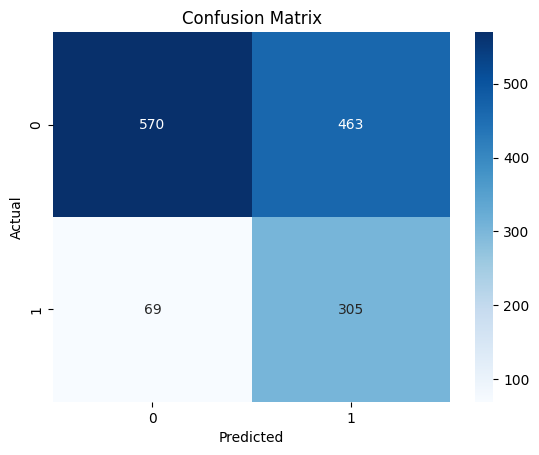

In [18]:
# confusion matrix

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Classification report

classificationReport = classification_report(y_test, y_pred)

print(classificationReport)

              precision    recall  f1-score   support

           0       0.89      0.55      0.68      1033
           1       0.40      0.82      0.53       374

    accuracy                           0.62      1407
   macro avg       0.64      0.68      0.61      1407
weighted avg       0.76      0.62      0.64      1407



In [20]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


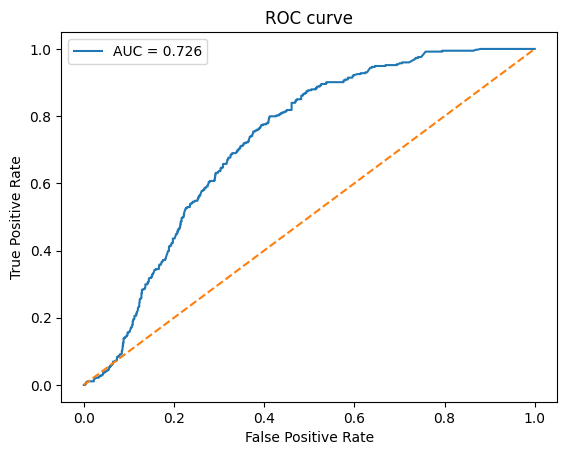

In [21]:
plt.Figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [22]:
coef_df = pd.DataFrame({
    "Features": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(10)

AttributeError: 'GradientBoostingClassifier' object has no attribute 'coef_'

In [ ]:
coef_df["abs_coef"] = coef_df["Coefficient"].abs()

coef_df.sort_values(by="abs_coef",ascending=False).head(10)

,Features,Coefficient,abs_coef
1,tenure,-1.347613,1.347613
2,MonthlyCharges,-0.851551,0.851551
10,InternetService_Fiber optic,0.727745,0.727745
3,TotalCharges,0.639028,0.639028
25,Contract_Two year,-0.602591,0.602591
24,Contract_One year,-0.310898,0.310898
21,StreamingTV_Yes,0.249702,0.249702
23,StreamingMovies_Yes,0.236368,0.236368
9,MultipleLines_Yes,0.214359,0.214359
28,PaymentMethod_Electronic check,0.181473,0.181473


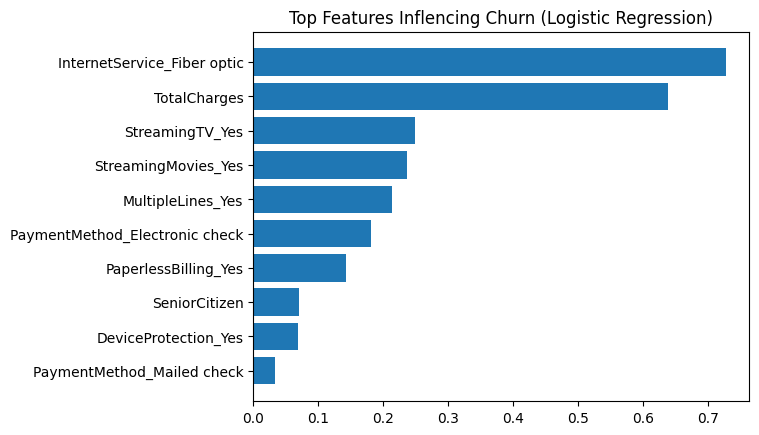

In [ ]:
top_features = coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

plt.Figure(figsize=(10,5))
plt.barh(top_features["Features"], top_features["Coefficient"])
plt.title("Top Features Inflencing Churn (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()